In [5]:
# Import required libraries
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ttest_ind

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
print("Libraries imported successfully.")


Libraries imported successfully.


In [6]:
# Find and load the Uber CSV files
DATA_DIR = "data"

files = sorted(glob.glob(os.path.join(DATA_DIR, "uber-raw-data-*.csv")))

if not files:
    # Also check the current directory in case the CSV files were placed there.
    files = sorted(glob.glob("uber-raw-data-*.csv"))

if not files:
    raise FileNotFoundError(
        "No Uber CSV files found. Put files such as "
        "'uber-raw-data-apr14.csv' inside a 'data' folder."
    )

print("Files found:")
for f in files:
    print(" -", f)

frames = []
for f in files:
    temp = pd.read_csv(f)
    frames.append(temp)

df = pd.concat(frames, ignore_index=True)

print("\nRaw dataset shape:", df.shape)
display(df.head())


Files found:
 - data\uber-raw-data-apr14.csv
 - data\uber-raw-data-aug14.csv
 - data\uber-raw-data-jul14.csv
 - data\uber-raw-data-jun14.csv
 - data\uber-raw-data-sep14.csv

Raw dataset shape: (3881892, 4)


,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [7]:
# Basic dataset information
print("Number of observations:", len(df))
print("Number of variables:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())


Number of observations: 3881892
Number of variables: 4

Columns:
['Date/Time', 'Lat', 'Lon', 'Base']

Data types:


,dtype
Date/Time,object
Lat,float64
Lon,float64
Base,object



Missing values:


,missing_values
Date/Time,0
Lat,0
Lon,0
Base,0



Duplicate rows: 72506


## 3. Data Preprocessing

The raw data is cleaned by:
1. Removing duplicate rows.
2. Converting `Date/Time` into datetime format.
3. Extracting hour, day, day of week, day name and month.
4. Checking for missing values.
5. Keeping latitude, longitude and base information for dataset documentation and exploratory analysis.


In [8]:
# Clean the data
df = df.drop_duplicates().copy()

df["Date/Time"] = pd.to_datetime(df["Date/Time"], errors="coerce")
df = df.dropna(subset=["Date/Time"])

df["Hour"] = df["Date/Time"].dt.hour
df["Day"] = df["Date/Time"].dt.day
df["DayOfWeek"] = df["Date/Time"].dt.dayofweek
df["DayOfWeekName"] = df["Date/Time"].dt.day_name()
df["Month"] = df["Date/Time"].dt.month
df["MonthName"] = df["Date/Time"].dt.month_name()

print("Cleaned dataset shape:", df.shape)
print("Duplicates remaining:", df.duplicated().sum())
print("Missing Date/Time values:", df["Date/Time"].isna().sum())

display(df.head())


Cleaned dataset shape: (3809386, 10)
Duplicates remaining: 0
Missing Date/Time values: 0


,Date/Time,Lat,Lon,Base,Hour,Day,DayOfWeek,DayOfWeekName,Month,MonthName
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0,1,1,Tuesday,4,April
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0,1,1,Tuesday,4,April
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0,1,1,Tuesday,4,April
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,0,1,1,Tuesday,4,April
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,0,1,1,Tuesday,4,April


In [9]:
# Dataset summary after preprocessing
dataset_summary = pd.DataFrame({
    "Property": [
        "Raw observations",
        "Cleaned observations",
        "Variables",
        "Date range",
        "Duplicate rows removed"
    ],
    "Value": [
        len(pd.concat(frames, ignore_index=True)),
        len(df),
        len(df.columns),
        f"{df['Date/Time'].min()} to {df['Date/Time'].max()}",
        len(pd.concat(frames, ignore_index=True)) - len(df)
    ]
})

display(dataset_summary)


,Property,Value
0,Raw observations,3881892
1,Cleaned observations,3809386
2,Variables,10
3,Date range,2014-04-01 00:00:00 to 2014-09-30 22:59:00
4,Duplicate rows removed,72506


## 4. Exploratory Data Analysis

The first part of the analysis looks at the overall pickup distribution and how demand changes with time.


In [10]:
# Descriptive statistics of the raw numeric variables
display(df[["Lat", "Lon", "Hour", "Day", "DayOfWeek", "Month"]].describe().round(2))


,Lat,Lon,Hour,Day,DayOfWeek,Month
count,3809386.00,3809386.00,3809386.00,3809386.00,3809386.00,3809386.00
mean,40.74,-73.97,14.17,15.96,2.94,7.13
std,0.04,0.06,5.98,8.72,1.89,1.65
min,39.66,-74.86,0.00,1.00,0.00,4.00
25%,40.72,-74.00,10.00,9.00,1.00,6.00
50%,40.74,-73.98,15.00,16.00,3.00,7.00
75%,40.76,-73.96,19.00,24.00,5.00,9.00
max,42.12,-72.07,23.00,31.00,6.00,9.00


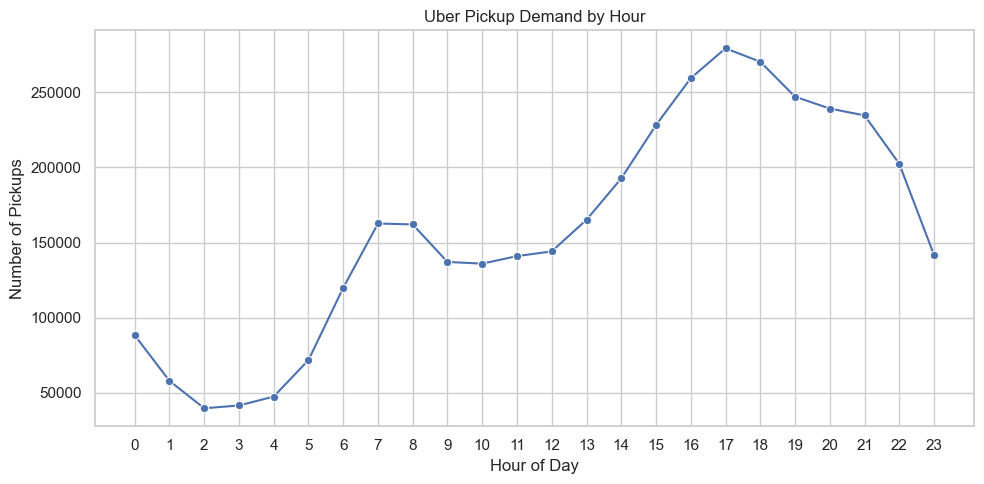

In [11]:
# Pickup count by hour
hour_counts = df.groupby("Hour").size().rename("Pickup_Count")

plt.figure(figsize=(10, 5))
sns.lineplot(x=hour_counts.index, y=hour_counts.values, marker="o")
plt.title("Uber Pickup Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Pickups")
plt.xticks(range(24))
plt.tight_layout()
plt.show()


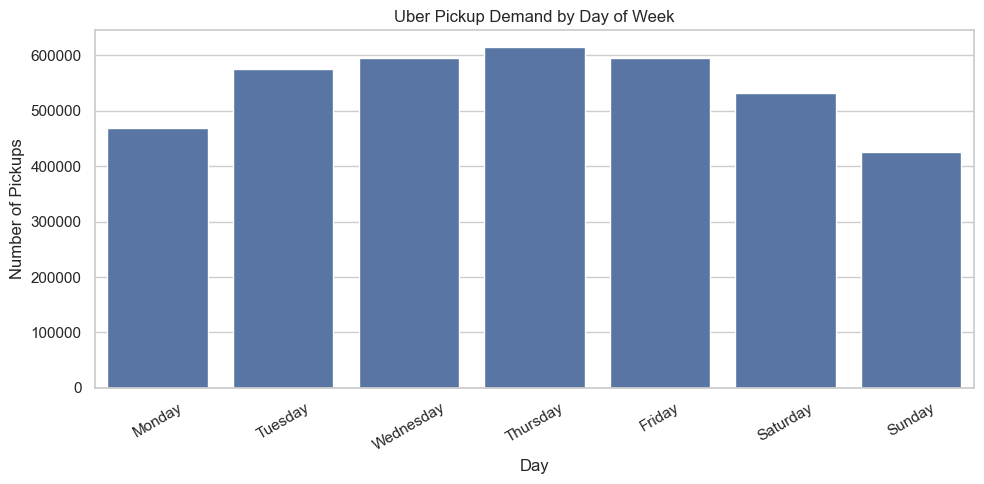

In [12]:
# Pickup count by day of week
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

weekday_counts = (
    df.groupby("DayOfWeekName")
      .size()
      .reindex(weekday_order)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_counts.index, y=weekday_counts.values)
plt.title("Uber Pickup Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Pickups")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


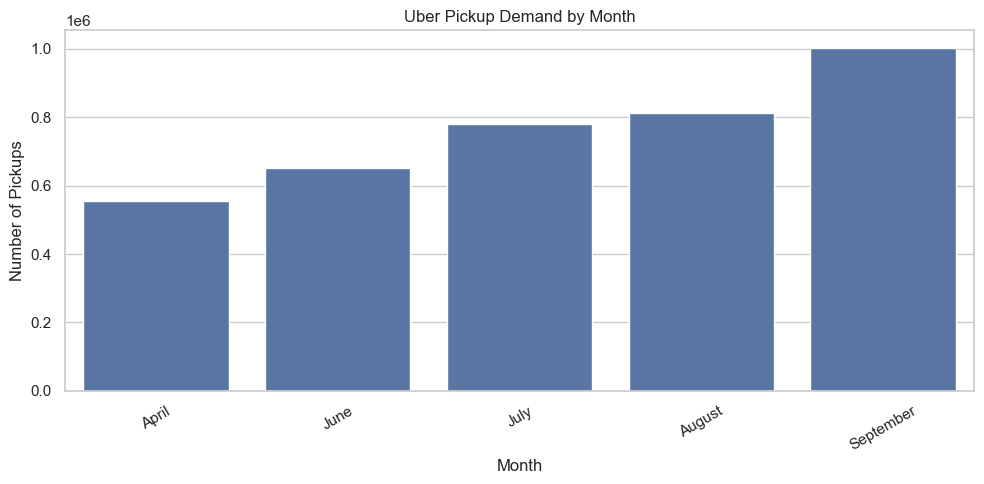

In [13]:
# Pickup count by month
month_counts = df.groupby(["Month", "MonthName"]).size().reset_index(name="Pickup_Count")
month_counts = month_counts.sort_values("Month")

plt.figure(figsize=(10, 5))
sns.barplot(data=month_counts, x="MonthName", y="Pickup_Count")
plt.title("Uber Pickup Demand by Month")
plt.xlabel("Month")
plt.ylabel("Number of Pickups")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


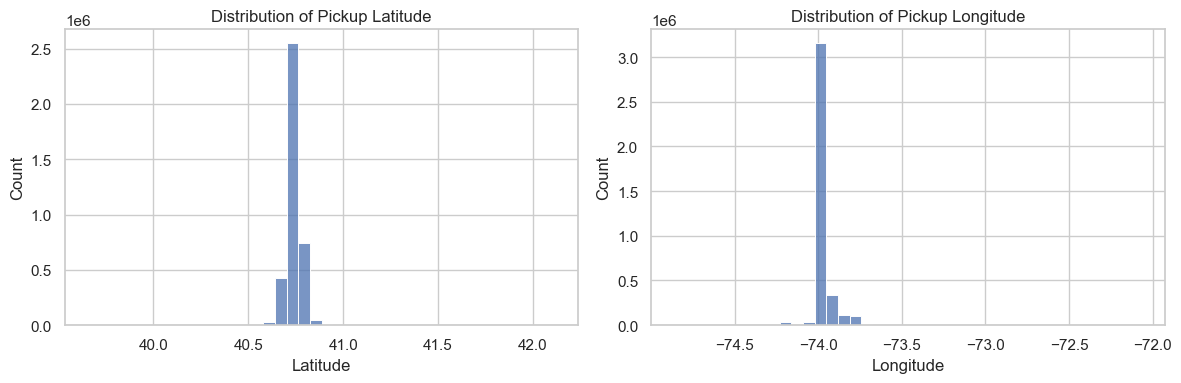

In [14]:
# Distribution of latitude and longitude
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Lat"], bins=40, ax=axes[0])
axes[0].set_title("Distribution of Pickup Latitude")
axes[0].set_xlabel("Latitude")

sns.histplot(df["Lon"], bins=40, ax=axes[1])
axes[1].set_title("Distribution of Pickup Longitude")
axes[1].set_xlabel("Longitude")

plt.tight_layout()
plt.show()


## 5. Statistical Analysis

For prediction, pickup events are aggregated by:

`Hour + Day + DayOfWeek + Month`

The number of records in each combination becomes `Pickup_Count`.

This converts the event-level data into a regression dataset where the target is a continuous count.


In [15]:
# Create the machine learning dataset
group_cols = ["Hour", "Day", "DayOfWeek", "Month"]

ml_df = (
    df.groupby(group_cols)
      .size()
      .reset_index(name="Pickup_Count")
)

print("ML dataset shape:", ml_df.shape)
display(ml_df.head())
display(ml_df["Pickup_Count"].describe().round(2).to_frame())


ML dataset shape: (3647, 5)


,Hour,Day,DayOfWeek,Month,Pickup_Count
0,0,1,0,9,682
1,0,1,1,4,133
2,0,1,1,7,210
3,0,1,4,8,717
4,0,1,6,6,1093


,Pickup_Count
count,3647.00
mean,1044.53
std,641.21
min,45.00
25%,517.00
50%,1003.00
75%,1450.00
max,3347.00


,Hour,Day,DayOfWeek,Month,Pickup_Count
Hour,1.000,-0.001,0.000,-0.001,0.630
Day,-0.001,1.000,0.028,0.009,0.048
DayOfWeek,0.000,0.028,1.000,0.008,-0.020
Month,-0.001,0.009,0.008,1.000,0.307
Pickup_Count,0.630,0.048,-0.020,0.307,1.000


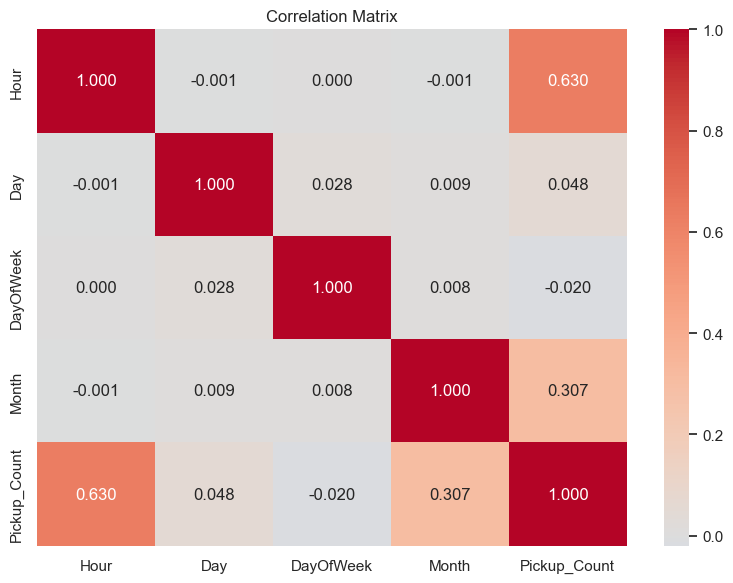

In [16]:
# Correlation analysis
corr_cols = ["Hour", "Day", "DayOfWeek", "Month", "Pickup_Count"]
corr = ml_df[corr_cols].corr()

display(corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [17]:
# 95% confidence interval for the mean pickup count
n = len(ml_df)
mean_count = ml_df["Pickup_Count"].mean()
std_count = ml_df["Pickup_Count"].std(ddof=1)
se = std_count / np.sqrt(n)

ci_low = mean_count - 1.96 * se
ci_high = mean_count + 1.96 * se

print(f"Mean Pickup_Count: {mean_count:.2f}")
print(f"95% confidence interval for mean: ({ci_low:.2f}, {ci_high:.2f})")


Mean Pickup_Count: 1044.53
95% confidence interval for mean: (1023.72, 1065.34)


In [18]:
# Hypothesis test: compare weekday and weekend pickup demand
weekday = df[df["DayOfWeek"] < 5].groupby(["Date/Time"]).size()
weekend = df[df["DayOfWeek"] >= 5].groupby(["Date/Time"]).size()

# Use daily counts for a clearer comparison
daily_counts = df.groupby(df["Date/Time"].dt.date).size().reset_index(name="Pickup_Count")
daily_dates = pd.to_datetime(daily_counts["Date/Time"])
daily_counts["DayOfWeek"] = daily_dates.dt.dayofweek

weekday_daily = daily_counts.loc[daily_counts["DayOfWeek"] < 5, "Pickup_Count"]
weekend_daily = daily_counts.loc[daily_counts["DayOfWeek"] >= 5, "Pickup_Count"]

t_stat, p_value = ttest_ind(weekday_daily, weekend_daily, equal_var=False)

print(f"Average weekday daily pickups: {weekday_daily.mean():.2f}")
print(f"Average weekend daily pickups: {weekend_daily.mean():.2f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: The difference is statistically significant at the 5% level.")
else:
    print("Result: The difference is not statistically significant at the 5% level.")


Average weekday daily pickups: 26154.69
Average weekend daily pickups: 22291.28
t-statistic: 2.929
p-value: 0.004659
Result: The difference is statistically significant at the 5% level.


## 6. Machine Learning Model

A Random Forest Regressor is used because pickup demand can depend on nonlinear combinations of time-related variables. It also gives a simple feature-importance measure for interpretation.

**Input features:** `Hour`, `Day`, `DayOfWeek`, `Month`  
**Target:** `Pickup_Count`

An 80:20 random split with `random_state=42` is used to match the documented project methodology.


In [19]:
# Prepare features and target
X = ml_df[["Hour", "Day", "DayOfWeek", "Month"]]
y = ml_df["Pickup_Count"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Model trained successfully.")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Model trained successfully.
Training samples: 2917
Testing samples: 730


In [20]:
# Model evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Value": [mae, mse, rmse, r2]
})

display(metrics.round(4))

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")


,Metric,Value
0,MAE,84.0619
1,MSE,16528.6204
2,RMSE,128.5637
3,R²,0.9607


MAE  : 84.06
MSE  : 16528.62
RMSE : 128.56
R²   : 0.9607


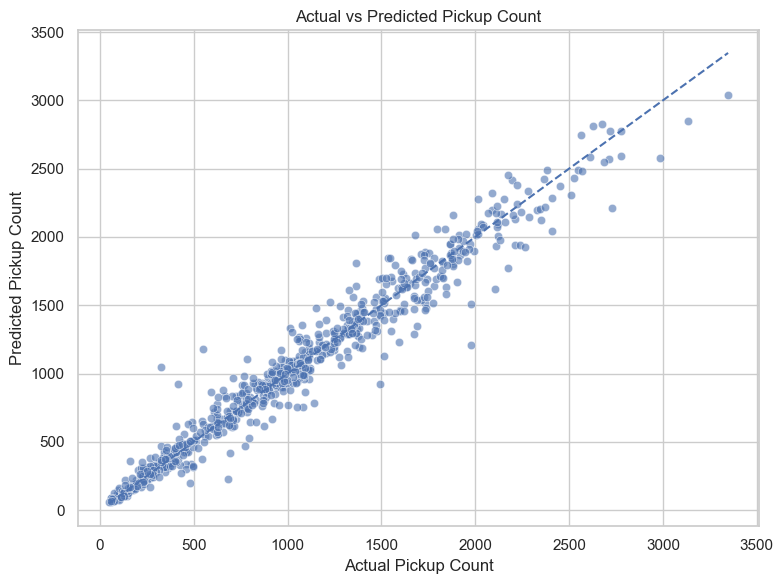

In [21]:
# Actual vs predicted values
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=comparison, x="Actual", y="Predicted", alpha=0.6)

line_min = min(comparison["Actual"].min(), comparison["Predicted"].min())
line_max = max(comparison["Actual"].max(), comparison["Predicted"].max())

plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")
plt.title("Actual vs Predicted Pickup Count")
plt.xlabel("Actual Pickup Count")
plt.ylabel("Predicted Pickup Count")
plt.tight_layout()
plt.show()


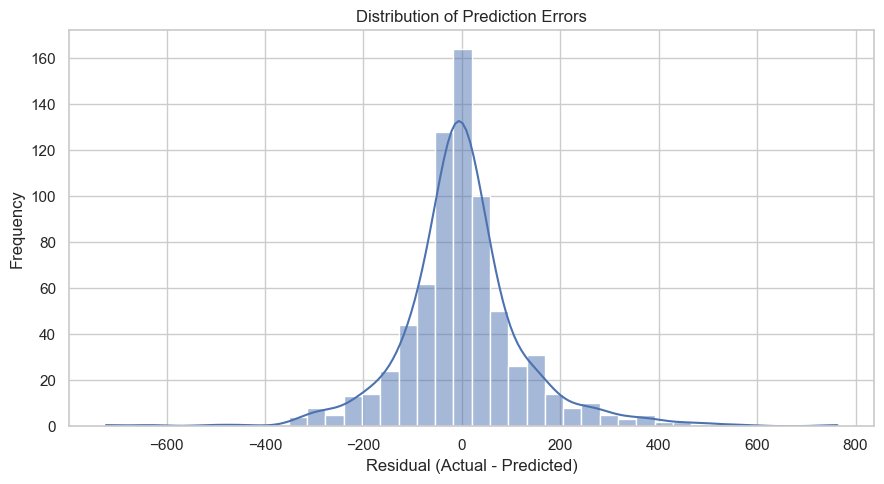

Mean residual: 1.5727397260273952


In [22]:
# Residual analysis
residuals = y_test - y_pred

plt.figure(figsize=(9, 5))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Mean residual:", residuals.mean())


,Feature,Importance
0,Hour,0.6438
2,DayOfWeek,0.1536
3,Month,0.1387
1,Day,0.0639


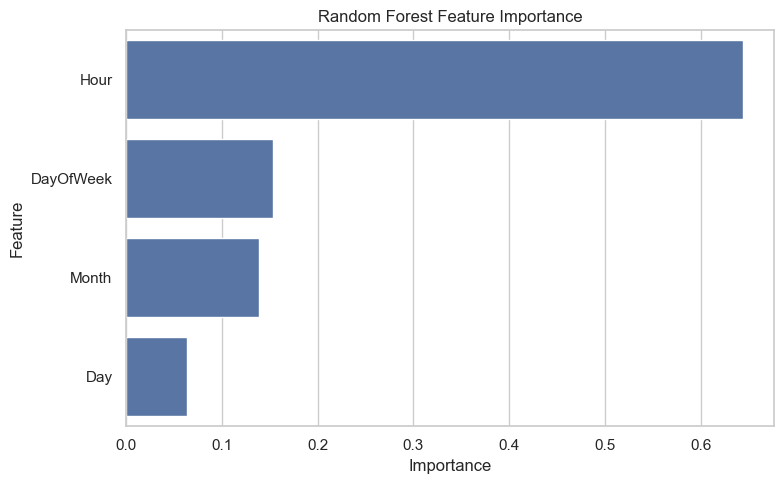

In [23]:
# Feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance.round(4))

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 7. Sample Prediction

The trained model can estimate pickup demand for a user-provided combination of hour, day, day of week and month.

The prediction should be treated as an estimate, especially for months or conditions that are not well represented in the historical training data.


In [24]:
# Example prediction
sample_input = pd.DataFrame({
    "Hour": [8],
    "Day": [20],
    "DayOfWeek": [2],   # Wednesday
    "Month": [7]
})

sample_prediction = model.predict(sample_input)[0]

print("Input:")
display(sample_input)

print(f"Estimated Pickup_Count: {sample_prediction:.0f}")


Input:


,Hour,Day,DayOfWeek,Month
0,8,20,2,7


Estimated Pickup_Count: 1429


In [27]:
# Interactive prediction function
def predict_pickups(model):
    try:
        hour = int(input("Enter Hour (0-23): "))
        day = int(input("Enter Day (1-31): "))
        day_of_week = int(input("Enter DayOfWeek (0=Monday, 6=Sunday): "))
        month = int(input("Enter Month (1-12): "))

        if not 0 <= hour <= 23:
            raise ValueError("Hour must be between 0 and 23.")
        if not 1 <= day <= 31:
            raise ValueError("Day must be between 1 and 31.")
        if not 0 <= day_of_week <= 6:
            raise ValueError("DayOfWeek must be between 0 and 6.")
        if not 1 <= month <= 12:
            raise ValueError("Month must be between 1 and 12.")

        user_input = pd.DataFrame({
            "Hour": [hour],
            "Day": [day],
            "DayOfWeek": [day_of_week],
            "Month": [month]
        })

        prediction = model.predict(user_input)[0]
        print(f"Estimated Pickup_Count: {prediction:.0f}")

    except ValueError as e:
        print("Invalid input:", e)


predict_pickups(model)


Enter Hour (0-23):  12
Enter Day (1-31):  22
Enter DayOfWeek (0=Monday, 6=Sunday):  6
Enter Month (1-12):  3


Estimated Pickup_Count: 602


In [28]:
predict_pickups(model)

Enter Hour (0-23):  22
Enter Day (1-31):  30
Enter DayOfWeek (0=Monday, 6=Sunday):  0
Enter Month (1-12):  6


Estimated Pickup_Count: 659
